# SnapBoost Classification Example

This notebook demonstrates binary classification with **SnapBoost** — a Heterogeneous Newton Boosting Machine that mixes decision trees and RBF kernel ridge regressors.

We compare SnapBoost against **XGBoost** and **LightGBM**, two standard gradient boosting libraries that use decision trees only.

We use the [Breast Cancer Wisconsin](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) dataset from scikit-learn.

> **Note:** XGBoost and LightGBM are optional notebook dependencies: `pip install xgboost lightgbm`

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, log_loss

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from snapboost import SnapBoostClassifier

## Load and split the data

In [2]:
X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")
print(f"Features:         {X_train.shape[1]}")

Training samples: 426
Test samples:     143
Features:         30


## Train SnapBoost

The breast cancer dataset is **tabular** — decision boundaries are mostly axis-aligned — so we set `p_tree=0.98` to rely almost entirely on trees rather than the RFF ridge learner. We also use **shallower trees** (depth 2–6) and **more boosting rounds** (250) than the library defaults.

Key parameters:
- `p_tree`: probability of selecting a decision tree (vs. RFF ridge) each iteration
- `min_max_depth` / `max_max_depth`: range of tree depths in the learner pool
- `num_iterations` / `learning_rate`: more rounds with moderate shrinkage improves accuracy on this dataset

In [3]:
N_ESTIMATORS = 250
LEARNING_RATE = 0.1
RANDOM_STATE = 42

model = SnapBoostClassifier(
    num_iterations=N_ESTIMATORS,
    learning_rate=LEARNING_RATE,
    p_tree=0.98,
    min_max_depth=2,
    max_max_depth=6,
    random_state=RANDOM_STATE,
    verbose=True,
)

model.fit(X_train, y_train)

Training:   0%|                                                                                                           | 0/250 [00:00<?, ?it/s]

Training:   9%|████████▉                                                                                        | 23/250 [00:00<00:01, 219.69it/s]

Training:  20%|███████████████████                                                                              | 49/250 [00:00<00:00, 239.27it/s]

Training:  30%|█████████████████████████████▍                                                                   | 76/250 [00:00<00:00, 249.53it/s]

Training:  40%|██████████████████████████████████████▊                                                         | 101/250 [00:00<00:00, 246.01it/s]

Training:  50%|████████████████████████████████████████████████▍                                               | 126/250 [00:00<00:00, 236.54it/s]

Training:  61%|██████████████████████████████████████████████████████████▎                                     | 152/250 [00:00<00:00, 240.26it/s]

Training:  71%|████████████████████████████████████████████████████████████████████▎                           | 178/250 [00:00<00:00, 240.41it/s]

Training:  81%|█████████████████████████████████████████████████████████████████████████████▉                  | 203/250 [00:00<00:00, 239.16it/s]

Training:  92%|████████████████████████████████████████████████████████████████████████████████████████▋       | 231/250 [00:00<00:00, 250.15it/s]

Training: 100%|████████████████████████████████████████████████████████████████████████████████████████████████| 250/250 [00:01<00:00, 242.06it/s]

,num_iterations,250
,learning_rate,0.1
,p_tree,0.98
,min_max_depth,2
,max_max_depth,6
,alpha,1.0
,gamma,1.0
,n_components,100
,random_state,42
,verbose,True


## Evaluate on the test set

In [4]:
accuracy = model.score(X_test, y_test)
print(f"Accuracy: {accuracy:.4f}")

test_log_loss = model.evaluate(X_test, y_test)

proba = model.predict_proba(X_test)
print(f"Probability matrix shape: {proba.shape}  # (n_samples, 2)")
print(f"Sample probabilities [P(y=0), P(y=1)]:\n{proba[:3]}")

Accuracy: 0.9720
Log Loss: 0.2531
Probability matrix shape: (143, 2)  # (n_samples, 2)
Sample probabilities [P(y=0), P(y=1)]:
[[1.79287133e-08 9.99999982e-01]
 [1.00000000e+00 1.21251497e-10]
 [1.51868853e-01 8.48131147e-01]]


## Compare with XGBoost and LightGBM

All three models use **250 boosting rounds** and learning rate 0.1. XGBoost and LightGBM use `max_depth=6`; SnapBoost stochastically picks tree depths from `[2, 6]` and occasionally selects an RFF ridge learner (`p_tree=0.98`).

In [5]:
MAX_DEPTH = 6

boosting_params = dict(
    n_estimators=N_ESTIMATORS,
    learning_rate=LEARNING_RATE,
    max_depth=MAX_DEPTH,
    random_state=RANDOM_STATE,
)

models = {
    "SnapBoost": model,
    "XGBoost": XGBClassifier(**boosting_params, eval_metric="logloss", verbosity=0),
    "LightGBM": LGBMClassifier(**boosting_params, verbosity=-1),
}

comparison = []
for name, fitted_model in models.items():
    if name != "SnapBoost":
        fitted_model.fit(X_train, y_train)
    y_pred = fitted_model.predict(X_test)
    accuracy = fitted_model.score(X_test, y_test)
    errors = (y_pred != y_test).sum()
    comparison.append(
        {"Model": name, "Accuracy": accuracy, "Test Errors": errors}
    )

comparison_df = pd.DataFrame(comparison).set_index("Model")
comparison_df

/home/samson/miniconda3/envs/qiancapital-dev/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/samson/miniconda3/envs/qiancapital-dev/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Accuracy,Test Errors
Model,,
SnapBoost,0.972028,4
XGBoost,0.958042,6
LightGBM,0.965035,5


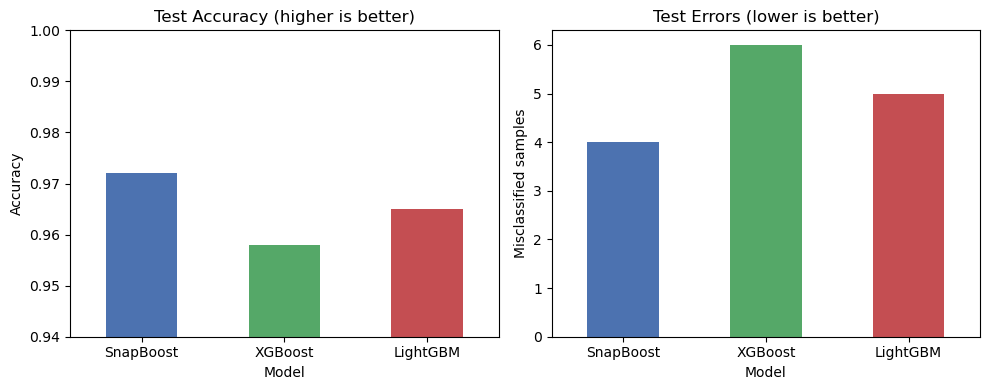

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ["#4C72B0", "#55A868", "#C44E52"]

comparison_df["Accuracy"].plot.bar(ax=axes[0], color=colors)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Test Accuracy (higher is better)")
axes[0].set_ylim(0.94, 1.0)
axes[0].tick_params(axis="x", rotation=0)

comparison_df["Test Errors"].plot.bar(ax=axes[1], color=colors)
axes[1].set_ylabel("Misclassified samples")
axes[1].set_title("Test Errors (lower is better)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [7]:
y_pred = model.predict(X_test)

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=["malignant", "benign"]))

Confusion matrix:
[[49  4]
 [ 0 90]]

              precision    recall  f1-score   support

   malignant       1.00      0.92      0.96        53
      benign       0.96      1.00      0.98        90

    accuracy                           0.97       143
   macro avg       0.98      0.96      0.97       143
weighted avg       0.97      0.97      0.97       143



## Confusion matrix heatmap

The heatmap below summarizes test-set predictions: rows are **actual** labels, columns are **predicted** labels. Darker cells mean more samples; the diagonal counts correct predictions.

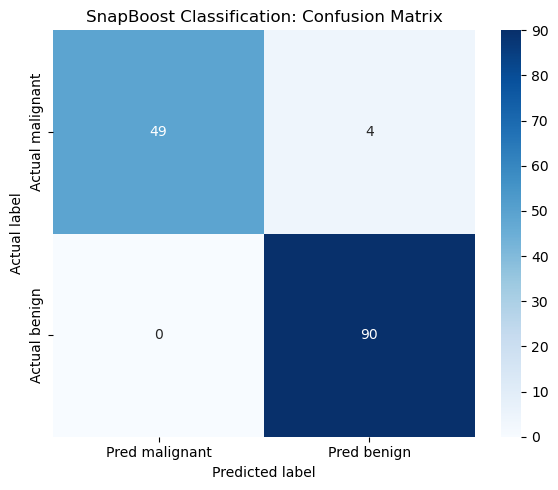

In [8]:
y_pred = model.predict(X_test)
labels = ["malignant", "benign"]
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=[f"Pred {name}" for name in labels],
    yticklabels=[f"Actual {name}" for name in labels],
    ax=ax,
)

ax.set_title("SnapBoost Classification: Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("Actual label")
plt.tight_layout()
plt.show()

## Inspect the ensemble

After training, fitted base learners are stored in `ensemble_`. SnapBoost randomly picks from trees at different depths and a kernel ridge model at each boosting round.

In [9]:
from sklearn.tree import DecisionTreeRegressor

from snapboost.rff_learner import RandomFourierRidgeRegressor

tree_count = sum(isinstance(l, DecisionTreeRegressor) for l in model.ensemble_)
ridge_count = sum(isinstance(l, RandomFourierRidgeRegressor) for l in model.ensemble_)

print(f"Ensemble size: {len(model.ensemble_)}")
print(f"  Decision trees:  {tree_count}")
print(f"  RFF ridge:       {ridge_count}")

Ensemble size: 250
  Decision trees:  249
  RFF ridge:       1
